In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
from pathlib import Path
from scipy.interpolate import make_smoothing_spline

from joblib import Parallel, delayed


# Load data

In [17]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'


In [19]:
normalization = 'TIC'
median_fn = metabolomics_folder / f'G_median_PI_{normalization}_norm_keio.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn, index_col=0)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_keio.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn, index_col=0)

In [20]:
df_w_mz = df_data.merge(df_ionMz, on='ionMz', how='left')

In [21]:
df = df_w_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

In [23]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

# Compare the timeseries of each strain with WT

## Define functions

In [36]:
def spline_distance_and_std2(data, g1, g2, group = 'Strain', xval = 'AUC OD', 
                            yval = 'Median Z-score', 
                            ystd = 'Z-score std',
                            lam = 10, n_x_grid = 100, uniform_grid = False,
                            permutations = False):
    """
    Calculate the distance between two splines fitted to the data for two groups.
    Args:
        data (pd.DataFrame): DataFrame containing the data.
        g1 (str): First group to compare.
        g2 (str): Second group to compare (WT).
        group (str): Column name for grouping.
        xval (str): Column name for x-axis values.
        yval (str): Column name for y-axis values.
        ystd (str): Column name for standard deviation of y-axis values.
        lam (float): Smoothing parameter for spline fitting (10-100 works well).
        n_x_grid (int): Number of points in the x grid for interpolation.
    Returns:
        rel_distance (float): Relative distance between the two splines.
        mean_diff (float): Mean difference between the two splines.
        mae1 (float): Mean absolute error for the first group.
        mae2 (float): Mean absolute error for the second group.
        mean_mae (float): Mean absolute error averaged over both groups.
    """

    dg1 = data.loc[data[group] == g1]
    dg2 = data.loc[data[group] == g2]
    
    x1 = dg1[xval].values
    y1 = dg1[yval].values
    y1std = dg1[ystd].values 

    x2 = dg2[xval].values
    y2 = dg2[yval].values
    y2std = dg2[ystd].values

    if uniform_grid:
        # Define common x grid (e.g., union or intersection)
        x_common = np.linspace(max(x1.min(), x2.min()), min(x1.max(), x2.max()), n_x_grid, endpoint=True)
    else:
        x_min = max(x1.min(), x2.min())
        x_max = min(x1.max(), x2.max())
        x_common = np.sort([x for x in np.concatenate((x1, x2)) if x_min <= x <= x_max])

    # Spline interpolation
    w1 = 1/y1std
    w2 = 1/y2std

    spline1  =  make_smoothing_spline(x1, y1, w = w1, lam =lam)
    spline2  =  make_smoothing_spline(x2, y2, w = w2, lam =lam)


    # Estimate distance
    spline_distance = spline1(x_common)-spline2(x_common)
    # Absolute mean distance
    mean_abs_diff = np.mean(np.abs(spline_distance))
    # Mean distance
    mean_diff = np.mean(spline_distance)

    # Mean absolute error
    mae1 = np.mean(np.abs(spline1(x1) - y1))
    mae2 = np.mean(np.abs(spline2(x2) - y2))
    mean_mae = (mae1 + mae2) / 2.0

    # Relative distance
    rel_abs_distance = mean_abs_diff / mean_mae
    rel_distance = mean_diff / mean_mae
    

    if permutations:
        return rel_abs_distance, mean_abs_diff
    else:
        return rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae



In [35]:
def perform_permutations2(n_perms, data, g1, g2, 
                        xval, yval, ystd, lam = 10, bar = False):
    perm_stats_rel = []
    perm_stats_abs = []
    # Make sure there are no duplicated x-values at all
    is_duplicated = data[xval].duplicated()
    if np.any(is_duplicated):
        # Add tiny random noise to the x-values to break ties
        data.loc[is_duplicated, xval] += np.sort(np.random.normal(0, 1e-4, size=is_duplicated.sum()))

    data.sort_values(by = xval, inplace = True, ascending= True)


    loop = tqdm(range(n_perms)) if bar else range(n_perms)
    
    for _ in loop:
        data['Group'] = np.random.permutation(data['Strain'])
        rel_dis, abs_dis = spline_distance_and_std2(data, g1 = g1, g2 = g2, group = 'Group', xval = xval,
                                        yval = yval, ystd = ystd, lam = lam, permutations = True)
        perm_stats_rel.append(rel_dis)
        perm_stats_abs.append(abs_dis)
    
    return perm_stats_rel, perm_stats_abs
    
def process_strain_metabolite_2(strain, mz, dfmz, n_perms, xval = 'AUC OD', yval = 'Median Z-score',
                                ystd = 'Z-score std', lam = 10):
    data = dfmz.copy()
    # print(data['Strain'].unique())
    g1, g2 = sorted(data['Strain'].unique(), reverse=True)

    # Make sure there are no duplicated x-values for the same strain 
    is_duplicated = data[['Strain', xval]].duplicated()
    if np.any(is_duplicated):
        # Add tiny random noise to the x-values to break ties
        data.loc[is_duplicated, xval] += np.random.normal(0, 1e-4, size=is_duplicated.sum())
    data.sort_values(by = xval, inplace=True)

    rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae = spline_distance_and_std2(data,g1=g1, g2=g2, group = 'Strain', xval= xval,
                                                            yval=yval, ystd = ystd,lam = lam, permutations = False)
    
    if n_perms > 0:
        perm_stats_rel, perm_stats_abs = perform_permutations2(n_perms, data, g1, g2, 
                                          xval, yval,ystd, lam=lam)
        p_value_rel = np.sum(np.array(perm_stats_rel) >= rel_abs_distance) / n_perms
        p_value_abs = np.sum(np.array(perm_stats_abs) >= mean_abs_diff) / n_perms
    else:
        p_value_rel = np.nan
        p_value_abs = np.nan
    return (strain, mz, rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs)

# Run screen

In [37]:
# Settings
xval = 'AUC OD'
yval = 'PI median'
ystd = 'PI std'
n_perms = 10
n_jobs = 8
lam = 10
wt_strain = 'WT'


In [38]:
dis_data = {}
run = True


In [39]:
if run:
    all_ions = df.ionMz.unique()
    all_strains = df.Strain.unique()
    jobs = []
    for i in range(len(all_strains)):
        strain = all_strains[i]
        if strain == 'WT':
            continue
        batch = df.loc[df.Strain==strain, 'Batch'].values[0]
        idxs = (df.Batch == batch)&(df.Strain.isin([strain, wt_strain]))
        dfs = df.loc[idxs]
        for mz in all_ions:
            if dis_data.get((strain, mz)):
                continue
            dfmz = dfs.loc[dfs.ionMz==mz]
            if len(dfmz) > 10:
                jobs.append((strain, mz, dfmz))

    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_strain_metabolite_2)(strain, mz, dfi, n_perms = n_perms, lam = lam, xval=xval, yval=yval, ystd = ystd)
        for strain, mz, dfi in jobs
    )

    # dis_data = {}
    for res in results:
        (strain, mz, rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs) = res
        dis_data[(strain, mz)] = [rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs]

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.9s
[Parallel(n_jobs=8)]: Done 976 tasks      | elapsed:    4.9s
[Parallel(n_jobs=8)]: Done 2976 tasks      | elapsed:   10.8s
[Parallel(n_jobs=8)]: Done 5776 tasks      | elapsed:   18.9s
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_31819/93999039.py:46: RuntimeWarning: divide by zero encountered in divide
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_31819/93999039.py:47: RuntimeWarning: divide by zero encountered in divide
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_31819/93999039.py:46: RuntimeWarning: divide by zero encountered in divide
[Parallel(n_jobs=8)]: Done 9376 tasks      | elapsed:   29.6s
[Parallel(n_jobs=8)]: Done 13776 tasks      | elapsed:   42.4s
[Parallel(n_jobs=8)]: Done 16907 out of 16907 | elapsed:   51.6s finished


## Save data

In [40]:
if run:
    dis_df = pd.DataFrame(dis_data).T.reset_index()
    dis_df.columns = ['Strain', 'ionMz', 'Rel. abs. distance', 'Rel. distance', 'Mean abs. distance', 'Mean distance',
                    'MAE1', 'MAE2', 'Mean MAE', 'Strain 1', 'Strain 2', 'p-value rel', 'p-value abs']

In [41]:
dis_df.loc[dis_df['Strain']=='tolC', 'ionMz'].nunique()

287

In [42]:
distance_fn = metabolomics_folder / f'K_timecurve_comparison_PI_{normalization}_norm_lam_{lam}_{xval}.csv'
dis_df.to_csv(distance_fn)

In [49]:
dis_df = dis_df.loc[~dis_df.Strain.isin(['dppB', 'tolC', 'ptsG'])]

<Axes: xlabel='Rel. distance', ylabel='Count'>

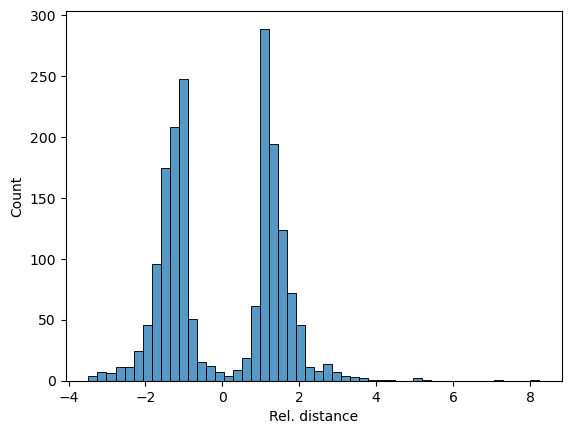

In [50]:
sns.histplot(dis_df.loc[dis_df['Rel. abs. distance']>1, 'Rel. distance'], bins=50)

In [51]:
dis_df.sort_values(by='Rel. abs. distance', ascending=False).head(10)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs
16143,kgtP,145.0141,8.24252,8.24252,10370.124114,10370.124114,2058.128048,458.122728,1258.125388,kgtP,WT,0.0,0.0
15403,metI,266.0703,7.198667,7.198667,4118.76329,4118.76329,916.582977,227.729778,572.156378,metI,WT,0.0,0.0
8551,glnP,130.0876,5.852197,5.383579,38871.024581,35758.406124,7713.925623,5570.3249,6642.125262,glnP,WT,0.0,0.0
8517,glnP,102.0562,5.156067,5.072281,13869.445999,13644.068459,4353.519469,1026.335214,2689.927342,glnP,WT,0.0,0.0
4277,putP,114.0560,5.134757,5.134757,2787.518825,2787.518825,960.407553,125.337629,542.872591,putP,WT,0.0,0.0
8532,glnP,116.0718,4.503809,4.427787,93316.955989,91741.810558,31334.580881,10104.546783,20719.563832,glnP,WT,0.0,0.0
13467,cstA,347.0398,4.470268,3.679011,9691.805334,7976.314361,3496.156472,839.962162,2168.059317,cstA,WT,0.0,0.0
14365,livH,88.0403,4.034709,4.022892,11342.742137,11309.522796,3441.877644,2180.705024,2811.291334,livH,WT,0.0,0.0
5215,adeP,344.0400,4.023557,-3.472838,12196.953129,-10527.510384,578.855691,5483.91537,3031.385531,adeP,WT,0.0,0.0
10743,galP,653.2613,3.911358,3.911358,638.755403,638.755403,217.076048,109.539618,163.307833,galP,WT,0.0,0.0


# Load data

In [139]:
dis_df = pd.read_csv(distance_fn, index_col=0)